[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Harvard-CS1090/2026-CS1090A-public/blob/sec02-2026/sec02/cs1090a_sec02_student.ipynb)

> **On Colab, do `File → Save a copy in Drive` before you start.** This notebook opens from GitHub, so you can type in it and run it right away — but nothing is being saved anywhere. Close the tab and the work is gone. Saving a copy first gives you one that persists in your own Drive.

## CS1090A Introduction to Data Science
# Section 2: Pandas & Plotting

**Harvard University**<br/>
**Fall 2026**<br/>
**Instructors**: Pavlos Protopapas and Kevin Rader<br/>
**Preceptor**: Chris Gumb

<hr style='height:2px'>

In [1]:
# Provided — setup. On Colab this fetches the data files this notebook needs.
# Everywhere else it does nothing except confirm they are already here.
#
# Generated at publish time; see utils/inject_colab_bootstrap.py. Editing this cell
# in the public repo is wasted work -- the next publish overwrites it.
import os
import shutil
import subprocess
import sys

_REPO    = "https://github.com/Harvard-CS1090/2026-CS1090A-public"
_REF     = "sec02-2026"
_SECTION = "sec02"

_DIRNAME = _REPO.rstrip("/").split("/")[-1].removesuffix(".git")

if os.path.isdir("data"):
    print(f"data/ is present -- nothing to fetch.")
elif "google.colab" not in sys.modules:
    raise RuntimeError(
        "This notebook reads its inputs from a data/ folder, which is not here.\n"
        "It does not fetch them from the live web -- that is deliberate, and Part 1\n"
        "explains why.\n\n"
        "Fix: get the whole folder, not just the notebook --\n"
        f"    git clone --branch {_REF} {_REPO}\n"
        f"    cd {_DIRNAME}/{_SECTION}\n"
        "    jupyter lab\n\n"
        "Then open this notebook from in there. (On Colab, this cell fetches it for you.)"
    )
else:
    print("Colab detected, no data/ -- fetching it once...")
    _tmp = "/content/_cs1090a_materials"
    if not os.path.isdir(_tmp):
        _r = subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", _REF, _REPO, _tmp],
            capture_output=True, text=True,
        )
        if _r.returncode != 0:
            raise RuntimeError(
                f"Could not download the data files from {_REPO} (ref {_REF}).\n\n"
                f"git said: {_r.stderr.strip().splitlines()[-1] if _r.stderr.strip() else 'no output'}\n\n"
                "This is not something you did wrong. Post on Ed with this message and\n"
                "a TF will sort it out; meanwhile the section notebook will not run here."
            )
    _dir = os.path.join(_tmp, _SECTION)
    _src = os.path.join(_dir, "data")
    if not os.path.isdir(_src):
        raise RuntimeError(
            f"Cloned {_REPO} at {_REF} but found no {_SECTION}/data in it.\n"
            "The published bundle is incomplete -- please report this on Ed."
        )
    shutil.copytree(_src, "data")

    # Sibling modules too, not just data/. Section 1 does `from section_helpers import
    # Recorded`; fetching data/ alone leaves that import failing three cells later,
    # which reads as "the notebook is broken" rather than "setup was incomplete".
    _mods = [f for f in os.listdir(_dir) if f.endswith(".py")]
    for _m in _mods:
        shutil.copy(os.path.join(_dir, _m), _m)

    print(f"data/ ready ({len(os.listdir('data'))} entries)"
          + (f", plus {', '.join(sorted(_mods))}." if _mods else "."))


Colab detected, no data/ -- fetching it once...
data/ ready (1 entries).


## How to read this notebook

<table style="border-collapse:separate; border-spacing:0 4px;">
<tr><td style="background:#FFF7CC; border-left:6px solid #D97706; padding:6px 12px; white-space:nowrap;"><strong>🤔 Predict</strong></td><td style="padding:6px 12px;">Commit to an answer <em>before</em> running the code.</td></tr>
<tr><td style="background:#E9F8EE; border-left:6px solid #16A34A; padding:6px 12px; white-space:nowrap;"><strong>🏋️ Exercise</strong></td><td style="padding:6px 12px;">You type. Usually filling blanks in a shape you have already run.</td></tr>
<tr><td style="background:#FDECEC; border-left:6px solid #DC2626; padding:6px 12px; white-space:nowrap;"><strong>💬 Discuss</strong></td><td style="padding:6px 12px;">Turn to a neighbour. Two minutes, out loud.</td></tr>
<tr><td style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:6px 12px; white-space:nowrap;"><strong>⭐ Insight</strong></td><td style="padding:6px 12px;">The one sentence to carry out of this part.</td></tr>
<tr><td style="background:#F3F4F6; border-left:6px solid #4B5563; padding:6px 12px; white-space:nowrap;"><strong>🧠 Takeaways</strong></td><td style="padding:6px 12px;">The whole hour, compressed.</td></tr>
</table>

Cells marked **`# Provided`** are complete — read them, run them, don't retype them.

<div style="background:#E8F1FF; border-left:6px solid #2563EB; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🎯 Objectives</div>
<div>
Lecture 2 introduced the DataFrame as a <em>concept</em>. This is where your hands learn it,
and every move below is one <strong>HW1 Questions 4, 5 or 8</strong> will ask you to make.
By the end you should be able to:

<ul>
<li>build a DataFrame from a <strong>list of dicts</strong> — the shape Section 1 left you in — and inspect it;</li>
<li>convert each column to the <strong>dtype that matches what it holds</strong>, using <code>to_datetime</code>, <code>to_timedelta</code>, and the <code>.dt</code> accessor;</li>
<li><strong>audit</strong> a frame: duplicates counted and dropped, missingness reported, rows with any NaN displayed;</li>
<li>group and reshape with <code>groupby</code> and <code>pivot_table</code>, including by calendar month;</li>
<li>plot from Pandas and seaborn, label it, and put <strong>two panels on a shared axis</strong>;</li>
<li>say what a chart <em>means</em>, and recognise one that runs without error and still misleads the reader;</li>
<li><strong>enrich</strong> a frame with a second table, verify the join, and save the result.</li>
</ul>

Deeper plotting syntax lives in the <strong>Matplotlib &amp; Seaborn reference</strong> supplemental;
extracting fields from cached pages (HW1 Q8.1) lives in the <strong>MediaWiki API</strong> supplemental.
This section does not duplicate either.
</div></div>

## Table of Contents

| | Part | Min |
|---|---|---:|
| 1 | [Load it, look at it](#Part-1.-Load-it,-look-at-it) — → Q4.1 | 5 |
| 2 | [Give each column the right dtype](#Part-2.-Give-each-column-the-right-dtype) — → Q4.3 | 13 |
| 3 | [Audit it, sort it](#Part-3.-Audit-it,-sort-it) — → Q4.1–4.2, Q4.4, Q5.1 | 13 |
| 4 | [Group it, reshape it](#Part-4.-Group-it,-reshape-it) — → Q4.5 | 6 |
| 5 | [Plot it, and plot it honestly](#Part-5.-Plot-it,-and-plot-it-honestly) — → Q5.2–5.5 | 23 |
| 6 | [Enrich it, ask it, save it](#Part-6.-Enrich-it,-ask-it,-save-it) — → Q8.1–8.3 | 7 |
| | transitions | 4 |
| | **total** | **71** |

Seventy-one minutes in a seventy-five-minute room. If you are running behind, the
**cut order is decided in advance** and is in `README.md` — Exercise 4 first, then
Exercise 2 becomes a walkthrough. **Exercise 1, Exercise 3 and Discussion 3 are never
cut**: each is the only rehearsal in Module 1 of something HW1 grades.

The **Appendix** after Part 6 is not section material. It is HW1 support to read afterwards.

In [2]:
# Provided. Run this first.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# The two knobs staff change each fall -- both here, at the top, on purpose.
SURVEY_CSV        = "data/survey_sim.csv"          # -> the real cleaned CSV once it exists
SURVEY_TERM_START = pd.Timestamp("2026-09-09")     # pinned so "age" is reproducible

## The data: a simulated version of your survey

We work with responses to the course intro survey. The real 2026 responses are not in
yet, so **this file is simulated** — 300 fake students, generated by
`utils/simulate_survey.py` with the same columns, the same messiness, and the same
missingness as the real thing.

That matters when you read the results. **Every *finding* below is fiction.** The
*mechanics* are real, and they are the point: the same calls, in the same order, on your
own HW1 data. Where a claim about the class appears, it carries a `CLAIM:` comment —
those are the sentences a section leader re-checks once the real data lands.

---
## Part 1. Load it, look at it

*(5 min — serves HW1 Q4.1)*

Section 1 left you with a **list of dicts** written to JSON. That is exactly what a
DataFrame is built from, so this is the join between the two sections.

In [3]:
# One row per dict, one column per key. This is Section 1's output shape.
records = [
    {"title": "Nosferatu", "theater": "Brattle",  "runtime": "1h 34m"},
    {"title": "Chinatown", "theater": "Coolidge", "runtime": "2h 10m"},
]
pd.DataFrame(records)

,title,theater,runtime
0,Nosferatu,Brattle,1h 34m
1,Chinatown,Coolidge,2h 10m


In [4]:
# HW1 does the same thing from a file: pd.read_json("data/movies.json")
# Here the survey arrives as CSV.
df = pd.read_csv(SURVEY_CSV)
df.shape

(300, 18)

In [5]:
df.head(3)

,program,jupyter,python_exp,pandas_skill,os,dark_mode,languages,continents,dob,wake_time,sleep_time,fav_season,caffeine,pet,fav_movie,fav_genres,hobbies,hw0
0,master's (ds),False,less than 1 year,3,macos,True,english,"asia, north america",2000-09-24,1900-01-01 07:30:00,1900-01-01 03:00:00,summer,tea,pet rock,NaN,comedy,"reading, hiking",NaN
1,master's (ds),False,1-2 years,3,wsl,True,"english, cantonese, portuguese, hindi","asia, north america",2004-08-08,1900-01-01 10:00:00,1900-01-01 23:15:00,spring,coffee,dog,Oppenheimer,drama,climbing,😀
2,mit master's,True,1-2 years,3,macos,False,"english, french, portuguese",north america,2008-01-07,1900-01-01 06:30:00,1900-01-01 00:00:00,spring,tea,none,Oppenheimer,"action, sci-fi",climbing,🤞


In [6]:
# dtypes and non-null counts in one view. Read the Dtype column skeptically.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   program       297 non-null    object
 1   jupyter       300 non-null    bool  
 2   python_exp    300 non-null    object
 3   pandas_skill  300 non-null    int64 
 4   os            300 non-null    object
 5   dark_mode     300 non-null    bool  
 6   languages     288 non-null    object
 7   continents    300 non-null    object
 8   dob           282 non-null    object
 9   wake_time     291 non-null    object
 10  sleep_time    291 non-null    object
 11  fav_season    296 non-null    object
 12  caffeine      297 non-null    object
 13  pet           294 non-null    object
 14  fav_movie     228 non-null    object
 15  fav_genres    279 non-null    object
 16  hobbies       258 non-null    object
 17  hw0           178 non-null    object
dtypes: bool(2), int64(1), object(15)
memory usage: 38.

Look at what `.info()` just told you: almost every column has dtype `object`, which is
the dtype Pandas falls back to for a column of strings with no more specific type. But `dob` holds
dates, and `python_exp` holds an ordered scale running from "none" to "a lot". A CSV file
stores every value as text and records no type information at all, so **converting each
column to the dtype that matches what it actually holds is our job**. It is also the first
thing HW1 Q4 asks for.

---
## Part 2. Give each column the right dtype

*(13 min — serves HW1 Q4.3)*

Two conversions carry most of the work, and HW1 Q4.3 names both: `screen_date` must
become a **datetime**, `runtime` must become a **timedelta**.

In [7]:
df.dtypes.head()

,0
program,object
jupyter,bool
python_exp,object
pandas_skill,int64
os,object


In [8]:
# A string column -> a real datetime column.
pd.to_datetime(df["dob"]).head(3)

,dob
0,2000-09-24
1,2004-08-08
2,2008-01-07


In [9]:
# Once it IS a datetime, the .dt accessor opens up: year, month, day, weekday...
pd.to_datetime(df["dob"]).dt.year.head(3)

,dob
0,2000.0
1,2004.0
2,2008.0


**Durations are a different type.** A datetime is a *point*; a timedelta is a *length*.
HW1's runtimes arrive as `"1h 34m"`, which is neither — it is a string, and Pandas needs
the units spelled out before it will parse them.

The `.str` accessor is how you apply a string method to a whole column at once.

In [10]:
# .str applies a string method down a Series -- NOT the same as Python's .replace
pd.Series(["1h 34m", "2h 10m"]).str.replace("h", " hours ")

,0
0,1 hours 34m
1,2 hours 10m


In [11]:
# Spelled-out units parse. This is the shape HW1 Q4.3 needs.
pd.to_timedelta(
    pd.Series(["1h 34m", "2h 10m"])
      .str.replace("h", " hours ")
      .str.replace("m", " minutes ")
)

,0
0,0 days 01:34:00
1,0 days 02:10:00


Now the assembly. Nothing below is new — every line is one you just ran.

In [12]:
# Provided: the three conversions applied to the real frame, then a re-check.
df["dob"] = pd.to_datetime(df["dob"], errors="coerce")
df["age"] = ((SURVEY_TERM_START - df["dob"]).dt.days / 365.25).round(1)

# wake - sleep, wrapped past midnight, as a real duration
df["sleep_len"] = pd.to_timedelta(
    (pd.to_datetime(df["wake_time"]) - pd.to_datetime(df["sleep_time"]))
    .dt.total_seconds() % (24 * 3600), unit="s"
)

df[["dob", "age", "sleep_len"]].dtypes          # verify, every time

,0
dob,datetime64[ns]
age,float64
sleep_len,timedelta64[ns]


<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 1: convert three columns to the right dtype (5 min)</div>
<div>
The same shape, on a small frame of screenings. <strong>Three blanks</strong>, each a line
you ran above:

<ol>
<li>parse <code>screen_date</code> into a datetime;</li>
<li>spell out the units in <code>runtime</code> with the <code>.str</code> accessor;</li>
<li>turn that into a timedelta.</li>
</ol>

Then run the last line and check the dtypes actually changed. <strong>This is HW1 Q4.3,
on two rows instead of two thousand.</strong>
</div></div>

In [13]:
films = pd.DataFrame({
    "title":       ["Nosferatu", "Chinatown"],
    "screen_date": ["2026-10-30", "2026-10-31"],
    "runtime":     ["1h 34m", "2h 10m"],
})

# your code here
films["screen_date"] = ...      # 1. parse it into a datetime
spelled = ...                   # 2. .str.replace the units into words
films["runtime"] = ...          # 3. that string -> a timedelta

films.dtypes

,0
title,object
screen_date,object
runtime,object


<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 1 (2 min)</div>
<div>
<strong>With a neighbour.</strong> A classmate leaves <code>screen_date</code> as a string and
sorts by it anyway. The output looks sorted. On <em>this</em> data it even <em>is</em> sorted.

What would have to be true of the dates for the string sort to silently disagree with the
real chronological order — and would you notice?
</div></div>

---
## Part 3. Audit it, sort it

*(13 min — serves HW1 Q4.1, Q4.2, Q4.4 and Q5.1)*

Before any analysis: how many rows are real, what is missing, and what order is it in?
HW1 Q4 asks for all three, in writing.

In [14]:
# How many rows are exact duplicates of another row?
df.duplicated().sum()

np.int64(0)

In [15]:
# The reportable pair HW1 Q4.1 wants: dropped, and remaining.
before = len(df)
after = len(df.drop_duplicates())
before, after, before - after

(300, 300, 0)

In [16]:
# Missing values per column. Only the columns that have any.
df.isna().sum()[lambda s: s > 0]

,0
program,3
languages,12
dob,18
wake_time,9
sleep_time,9
fav_season,4
caffeine,3
pet,6
fav_movie,72
fav_genres,21


In [17]:
# Q4.2 asks for rows with AT LEAST ONE NaN -- .any(axis=1), not a count threshold.
df.isna().any(axis=1).sum()

np.int64(205)

In [18]:
# Sorting returns a new frame. Ascending is the default.
df.sort_values("dob").head(3)[["program", "dob", "age"]]

,program,dob,age
273,master's (ds),1985-01-27,41.6
130,hks master's,1986-06-14,40.2
171,hks master's,1986-09-22,40.0


In [19]:
# Descending, top five -- the exact shape HW1 Q5.1 asks for.
df.sort_values("age", ascending=False).head(5)[["program", "dob", "age"]]

,program,dob,age
273,master's (ds),1985-01-27,41.6
130,hks master's,1986-06-14,40.2
171,hks master's,1986-09-22,40.0
286,master's (ds),1986-11-20,39.8
222,mit master's,1987-07-09,39.2


The assembly. Note the `.head(10)` on the last line: there are hundreds of rows with a
missing value, and a cell that prints all of them is unreadable in the notebook and worse
in a PDF a TF has to read. **Print a slice.**

In [20]:
# A parsed date is not a PLAUSIBLE date. errors="coerce" catches gibberish; it does not
# catch a student who typed this year as their birth year. Surveys always have a few.
implausible = df["age"].notna() & ~df["age"].between(16, 100)
df.loc[implausible, ["dob", "age"]]

,dob,age
80,2024-12-22,1.7
221,2025-11-23,0.8
257,2025-04-08,1.4


Three self-reported toddlers. They parsed perfectly and they are nonsense — **a dtype
conversion is not validation.** This is what HW1 Q4's *"verify as you go"* is asking for,
and it is why the audit comes before the analysis rather than after it.

We exclude them from the age work below and say so. Silently dropping rows is how a
result becomes unreproducible; dropping them in a cell with a printed count is not.

In [21]:
# Provided: the whole audit, as HW1 Q4 wants it reported.
before = len(df)
df = df.drop_duplicates()
print(f"dropped {before - len(df)} duplicate rows; {len(df)} remain")

print(f"rows with at least one missing value: {df.isna().any(axis=1).sum()}")
print(f"excluding {implausible.sum()} implausible ages from the age analyses")
df = df[~implausible]

df[df.isna().any(axis=1)].head(10)[["program", "dob", "fav_movie", "hobbies"]]

dropped 0 duplicate rows; 300 remain
rows with at least one missing value: 205
excluding 3 implausible ages from the age analyses


,program,dob,fav_movie,hobbies
0,master's (ds),2000-09-24,NaN,"reading, hiking"
4,master's (ds) [extension school],2003-08-08,NaN,"reading, hiking"
8,bachelor's (am),1992-04-24,NaN,NaN
9,master's (ds) [extension school],1999-11-15,Oppenheimer,"cooking, movies"
10,bachelor's (statistics),2007-03-07,The Matrix,"cooking, movies"
11,bachelor's (cs),1999-06-01,Oppenheimer,"music, running"
12,master's (ds),2000-02-07,Spirited Away,climbing
14,master's (ds) [extension school],2005-09-07,NaN,"reading, hiking"
16,master's (ds),2002-03-17,The Matrix,climbing
20,hks master's,2005-06-08,Oppenheimer,NaN


<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 2: audit the screenings (5 min)</div>
<div>
Your turn, on the film frame. <strong>Four blanks</strong>, all run above:

<ol>
<li>drop the duplicate rows;</li>
<li>count the rows with <strong>at least one</strong> missing value;</li>
<li>show a bounded slice of them;</li>
<li>sort by <code>screen_date</code>, ascending — <strong>HW1 Q4.4</strong>.</li>
</ol>
</div></div>

In [22]:
screenings = pd.DataFrame({
    "title":       ["Nosferatu", "Chinatown", "Nosferatu", "Alien", "Alien"],
    "theater":     ["Brattle", "Coolidge", "Brattle", "Somerville", None],
    "screen_date": pd.to_datetime(["2026-10-30", "2026-10-31", "2026-10-30",
                                   "2026-10-29", "2026-11-01"]),
    "genre":       ["Horror", "Noir", "Horror", None, "Horror"],
})

# your code here
n_before = len(screenings)
screenings = ...                                  # 1. drop the duplicate rows
print(f"dropped {n_before - len(screenings)}; {len(screenings)} remain")

print("rows with any NaN:", ...)                  # 2. .any(axis=1), not a threshold
display(...)                                      # 3. a BOUNDED slice of them

screenings = ...                                  # 4. sort ascending by screen_date

screenings

TypeError: object of type 'ellipsis' has no len()

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 2 (2 min)</div>
<div>
<strong>With a neighbour.</strong> This survey had almost no duplicates — the file was already
cleaned. <strong>Your HW1 scrape will have plenty.</strong>

Where do they come from, given how you collected it in Section 1? And would
<code>drop_duplicates()</code> catch a screening that appears twice with the runtime written
<code>"1h 34m"</code> once and <code>"94 min"</code> the other time?
</div></div>

<div style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">⭐ Insight</div>
<div>
<strong>Audit before you analyse, and report the numbers.</strong>

"I dropped 412 duplicate rows; 1,906 remain; 38 rows have a missing genre" is a sentence a
reader can check. A clean-looking table is not. Every count you print is a claim you have
made checkable — and HW1 Q4 grades the counts, not the tidiness.
</div></div>

---
## Part 4. Group it, reshape it

*(6 min — serves HW1 Q4.5. Provided walkthrough: read and run, no blanks.)*

`groupby` answers "a statistic per group". `pivot_table` lays two groupings out as rows ×
columns, which is usually what a human wants to read. HW1 Q4.5 asks for exactly that
shape: **screenings per theater per calendar month**.

In [54]:
# Counts per category -- the most-used line in all of EDA.
df["program"].value_counts().head(4)

,count
program,
master's (ds),73
bachelor's (cs),63
master's (ds) [extension school],35
bachelor's (statistics),33


In [55]:
# A datetime -> the calendar month it falls in. (HW1's reference solution uses this;
# any correct month bucketing is fine.)
df["dob"].dt.to_period("M").head(3)

,dob
0,2000-09
1,2004-08
2,2008-01


In [56]:
# Group by a period and count. size() counts rows per group.
# "Y" here because birthdays span decades; HW1 Q4.5 wants "M", because screen dates
# span months. Same call, and the period you pick is the question you are asking.
df.groupby(df["dob"].dt.to_period("Y")).size().tail(4)

,0
dob,
2005,18
2006,25
2007,24
2008,22


In [57]:
# Restricting to the busiest groups keeps a table readable.
top = df["program"].value_counts().head(4).index
top

Index(['master's (ds)', 'bachelor's (cs)', 'master's (ds) [extension school]',
       'bachelor's (statistics)'],
      dtype='object', name='program')

In [58]:
# .isin turns that list of labels into a row mask.
df["program"].isin(top).head()

,program
0,True
1,True
2,False
3,True
4,True


In [59]:
# Provided: rows x columns, on a frame shaped like HW1's. This IS Q4.5 --
# screenings per theater per calendar month.
sched = pd.DataFrame({
    "theater":     ["Brattle", "Coolidge", "Brattle", "Somerville", "Brattle",
                    "Coolidge", "Somerville", "Brattle", "Coolidge"],
    "screen_date": pd.to_datetime(["2026-09-03", "2026-09-14", "2026-10-02",
                                   "2026-10-11", "2026-10-30", "2026-10-31",
                                   "2026-11-05", "2026-11-19", "2026-11-22"]),
})
sched["month"] = sched["screen_date"].dt.to_period("M")

sched.pivot_table(index="month", columns="theater", aggfunc="size", fill_value=0)

theater,Brattle,Coolidge,Somerville
month,,,
2026-09,1,1,0
2026-10,2,1,1
2026-11,1,1,1


**And say what you see** — Q4.5 asks for the table *and* a sentence about it.

> *The Brattle appears in all three months and carries the most screenings; the
> Somerville appears in only two. October is the busiest month for every venue that
> appears in it.*

The cell worth staring at is the **zero**. `fill_value=0` wrote it, but a zero here can
mean two completely different things: *that theater ran nothing that month*, or *our
snapshots never covered that month*. In HW1 it is usually the second — months far from a
snapshot date look quiet because you **sampled** them less, not because Boston stopped
showing films. An empty cell is usually a fact about your collection process, and it is
the thing most likely to mislead you in Question 9.

---
## Part 5. Plot it, and plot it honestly

*(23 min — serves HW1 Q5.2, Q5.3, Q5.4 and Q5.5. The biggest block, on purpose:
Lecture 3 is next week, and HW1 needs this now.)*

<Axes: ylabel='caffeine'>

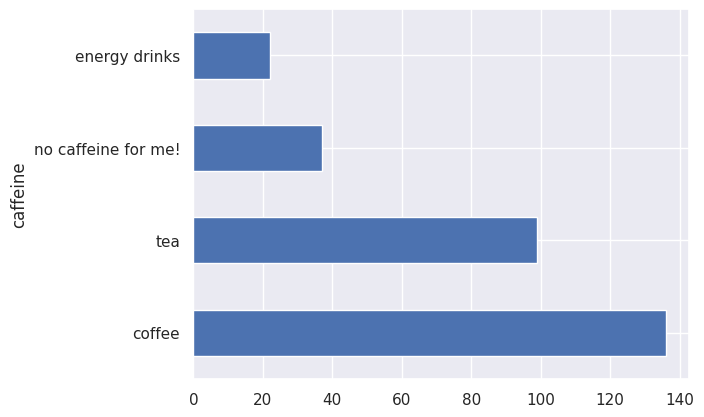

In [60]:
# Every Series has .plot -- the fastest route from a question to a picture.
df["caffeine"].value_counts().plot(kind="barh")

That drew something, and it also **returned** something: an **Axes**, the object a plot is
drawn on. `.plot()` will hand it to you, and you could label it from there.

The habit worth building instead is making the Axes *first* and passing it in with `ax=`.
It reads the same for one panel and it is the habit that scales to several — which is where
HW1 Q5.2 is going.

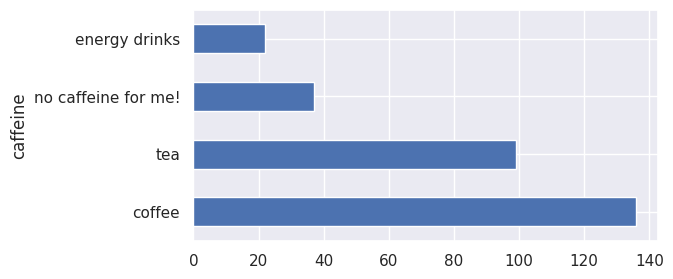

In [61]:
fig, ax = plt.subplots(figsize=(6, 3))
df["caffeine"].value_counts().plot(kind="barh", ax=ax)
plt.show()

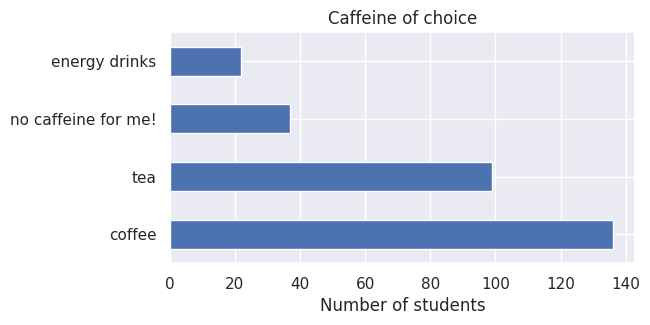

In [62]:
# The labeling trio. HW1 Q5 requires all three on every plot, every time.
fig, ax = plt.subplots(figsize=(6, 3))
df["caffeine"].value_counts().plot(kind="barh", ax=ax)
ax.set_xlabel("Number of students")
ax.set_ylabel("")
ax.set_title("Caffeine of choice")
plt.show()

**seaborn** plots straight from a DataFrame: name the columns, get sensible defaults.
Q5.3 wants a distribution **overall** *and* **broken out by group** — those are two
different plots, and choosing between them is half the question.

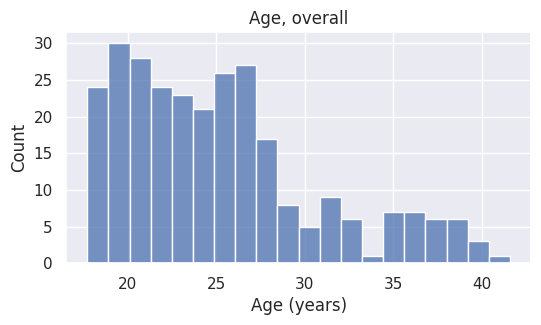

In [63]:
# Overall: one distribution, all students.
fig, ax = plt.subplots(figsize=(6, 3))
sns.histplot(data=df, x="age", bins=20, ax=ax)
ax.set_xlabel("Age (years)")
ax.set_title("Age, overall")
plt.show()

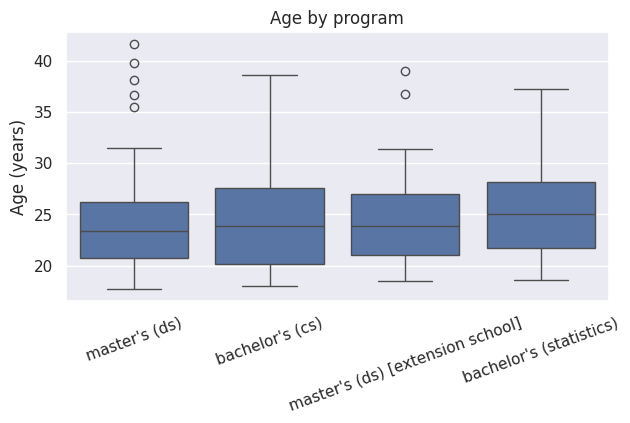

In [64]:
# Broken out: the same variable, one box per group. Comparison becomes readable.
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.boxplot(data=df[df["program"].isin(top)], x="program", y="age", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Age (years)")
ax.set_title("Age by program")
plt.tick_params(axis="x", rotation=20)
plt.show()

Now the move HW1 Q5.2 asks for by name: **two panels side by side, sharing a y-axis.**

<div style="background:#FFF7CC; border-left:6px solid #D97706; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🤔 Predict (1 min)</div>
<div>
<code>fig, ax = plt.subplots()</code> gave you one Axes.

<strong>Before you run the next cell:</strong> what does <code>plt.subplots(1, 2)</code> give
you as its second value? Commit to an answer — an Axes? two Axes? something else? — then run it.
</div></div>

In [65]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2.5))
plt.close(fig)                      # we only want to look at what axs IS
type(axs), axs.shape

(numpy.ndarray, (2,))

If you guessed "an Axes", you are in good company, and that guess is the single most
common way this cell fails for people: `axs.set_title(...)` raises an `AttributeError`
that does not obviously say *"you have two of these, not one"*.

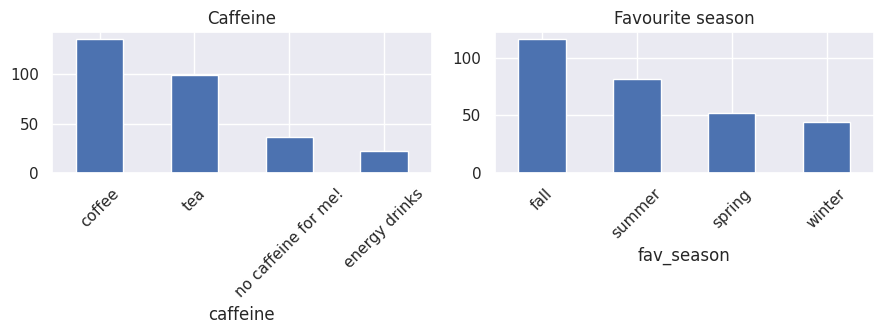

In [66]:
# So you index into it, and each panel gets its own plot and its own labels.
# Vertical bars, because the next step shares the y-axis and y must hold the counts.
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5))
df["caffeine"].value_counts().plot(kind="bar", ax=axs[0])
df["fav_season"].value_counts().plot(kind="bar", ax=axs[1])
axs[0].set_title("Caffeine")
axs[1].set_title("Favourite season")
for ax in axs:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

Now the part that is easy to get backwards. **`sharey=True` shares the y-axis — so it only
helps if the y-axis is the one holding the *counts*.**

Horizontal bars (`barh`) put the categories on y and the counts on x. Sharing y would then
force two unrelated category lists onto one axis, which is meaningless. **Vertical bars
put counts on y**, so that is what you want here — and it is what HW1 Q5.2's own answer
uses.

> **The rule:** share whichever axis holds the numbers. Vertical bars (`bar`) put the
> numbers on y, so pass `sharey=True`. Horizontal bars (`barh`) put the numbers on x, so
> pass `sharex=True`.

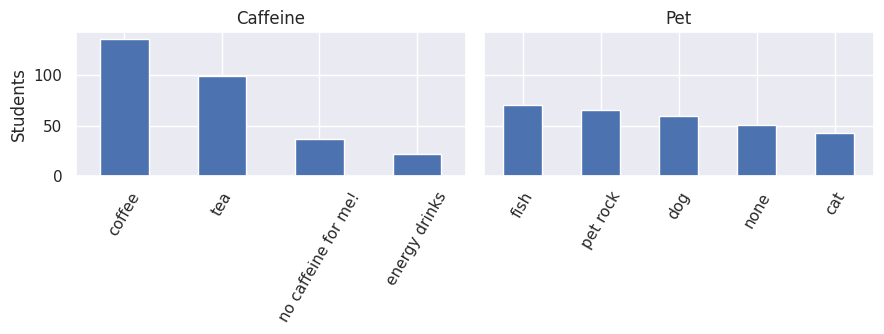

In [67]:
# Provided: the Q5.2 shape, complete. VERTICAL bars, so the shared axis is the count.
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
df["caffeine"].value_counts().plot(kind="bar", ax=axs[0])
df["pet"].value_counts().plot(kind="bar", ax=axs[1])
axs[0].set_title("Caffeine")
axs[1].set_title("Pet")
axs[0].set_ylabel("Students")            # labelled once: the axis is shared
for ax in axs:
    ax.tick_params(axis="x", rotation=60)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

> *Interpretation: the shared y-axis is doing the work here. Because both panels sit on
> one count scale, the eye can compare bar **heights** across panels, not just within one —
> the most common caffeine answer (136 students) is visibly taller than the most common pet
> answer (71). Draw these as two separate figures and that comparison quietly stops being
> valid, because each figure would pick its own y-limits.*

**That paragraph is not decoration.** HW1 Q5 requires a written interpretation under
*every* visualization, and a sentence naming what the chart lets you say is what earns it.

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 3: two panels, shared y-axis (6 min)</div>
<div>
<strong>HW1 Q5.2, exactly.</strong> Three blanks:

<ol>
<li>make a 1×2 figure with a <strong>shared y-axis</strong>;</li>
<li>draw <code>theater</code> counts on the <strong>first</strong> panel;</li>
<li>draw <code>genre</code> counts on the <strong>second</strong>.</li>
</ol>

Both panels use <code>kind="bar"</code> — vertical — so the shared y-axis is the count.
The titles and labels are already written; they are not optional.
</div></div>

In [68]:
plays = pd.DataFrame({
    "theater": ["Brattle", "Coolidge", "Brattle", "Somerville", "Brattle", "Coolidge"],
    "genre":   ["Horror", "Noir", "Horror", "Horror", "Drama", "Drama"],
})

# your code here
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5), ...)       # 1. share the y-axis
plays["theater"].value_counts().plot(kind="bar", ax=...)   # 2. first panel
plays["genre"].value_counts().plot(kind="bar", ax=...)     # 3. second panel

axs[0].set_title("Screenings by theater")
axs[1].set_title("Screenings by genre")
axs[0].set_ylabel("Screenings")          # labelled once: the axis is shared
for ax in axs:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

SyntaxError: positional argument follows keyword argument (1594013671.py, line 7)

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 4: say what it means (3 min — no code)</div>
<div>
Look back at the <strong>age by program</strong> boxplot earlier in this part. Write
<strong>two sentences</strong> in the cell below:

<ol>
<li><strong>What does it mean?</strong> Not what it shows — what it lets you conclude.</li>
<li><strong>Why a boxplot rather than the histogram?</strong> Q5.3 asks you to justify the
plot type, and "it looked nicer" is not a justification.</li>
</ol>

Remember the data is simulated, so write about what the <em>shape</em> would tell you.
</div></div>

*your answer here*

### When a chart runs without error and still misleads

Everything above was about making a chart. This is about **reading** one.

The cell below is the kind of thing an over-eager assistant produces: it runs without
error, it looks professional, and it is dishonest. **HW1 Q5.5 asks you to take one
apart.**

In [ ]:
# Provided -- deliberately misleading. Do not copy this into your homework.
means = df.groupby("dark_mode")["age"].mean()

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(["light mode", "dark mode"], means.values, color="crimson")
ax.set_ylim(means.min() - 0.15, means.max() + 0.15)      # (1)
ax.set_title("Dark-mode users are FAR younger!")          # (2)
ax.set_ylabel("Age")
plt.show()

print(means.round(2).to_string())

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 3 (4 min)</div>
<div>
<strong>With a neighbour.</strong> The code above ran without an error and the chart looks
polished. The printed means are right there underneath it.

<ol>
<li>What <strong>claim</strong> does the chart make?</li>
<li>Name <strong>three specific choices</strong> that make it misleading.</li>
<li>What would an <strong>honest</strong> version look like?</li>
</ol>

This is HW1 Q5.5 with the answer said out loud instead of written down.
</div></div>

In [ ]:
# Provided: the honest redraw. Same data, same three lines of computation.
fig, ax = plt.subplots(figsize=(6, 3.2))
sns.boxplot(data=df, x="dark_mode", y="age", ax=ax)
ax.set_xlabel("Prefers dark mode")
ax.set_ylabel("Age (years)")
ax.set_title(f"Mean age differs by {abs(means.diff().iloc[-1]):.1f} years; "
             f"the distributions overlap")
plt.show()

<div style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">⭐ Insight</div>
<div>
<strong>A chart that runs is not a chart that is true.</strong>

Every tool you use will happily draw a truncated axis under an editorial title. The
error-free execution tells you nothing about the honesty of the result — you are the only
check there is, which is what HW1 Q5.5 is really testing.
</div></div>

---
## Part 6. Enrich it, ask it, save it

*(7 min — serves HW1 Q8.1, Q8.2 and Q8.3)*

Real analyses combine tables. HW1 Q8 has you pull a field off each film's cached
Wikipedia page and join it onto your frame — *how* to extract it is the **MediaWiki API
supplemental**'s job; the **join**, and what you do with it afterwards, is this part's.

In [23]:
# A lookup table, built by hand. Small, and keyed on a column df already has.
caffeine_mg = pd.DataFrame({
    "caffeine": ["coffee", "tea", "energy drinks", "no caffeine for me!"],
    "mg_per_serving": [95, 47, 80, 0],
})
caffeine_mg

,caffeine,mg_per_serving
0,coffee,95
1,tea,47
2,energy drinks,80
3,no caffeine for me!,0


In [24]:
# Snapshot the row count BEFORE the join -- you cannot check what you did not record.
n_before = len(df)
n_before

297

In [25]:
# how="left" keeps every row on the left; unmatched keys get NaN.
df = df.merge(caffeine_mg, on="caffeine", how="left")
df[["caffeine", "mg_per_serving"]].head(3)

,caffeine,mg_per_serving
0,tea,47.0
1,coffee,95.0
2,tea,47.0


In [26]:
# The verification habit, as code. This cell FAILS if the merge misbehaved.
assert len(df) == n_before, f"merge changed the row count! {n_before} -> {len(df)}"
assert df["mg_per_serving"].isna().sum() == df["caffeine"].isna().sum(), \
    "some caffeine values found no match in the lookup"
print(f"{len(df)} rows in, {len(df)} rows out; unmatched: "
      f"{df['mg_per_serving'].isna().sum()}")

297 rows in, 297 rows out; unmatched: 3


In [27]:
# Aggregating the merged-in column is where the join starts paying.
df.groupby("fav_season")["mg_per_serving"].mean().round(1)

,mg_per_serving
fav_season,
fall,67.1
spring,62.9
summer,71.0
winter,57.3


In [28]:
# Sorted, so the chart below has a readable order.
df.groupby("fav_season")["mg_per_serving"].mean().sort_values(ascending=False).round(1)

,mg_per_serving
fav_season,
summer,71.0
fall,67.1
spring,62.9
winter,57.3


### The whole chain, once, in the shape HW1 Q8.2 grades

Q8.2 asks for four things, and it is easy to produce the plot and forget the other three.
Here they are, labelled.

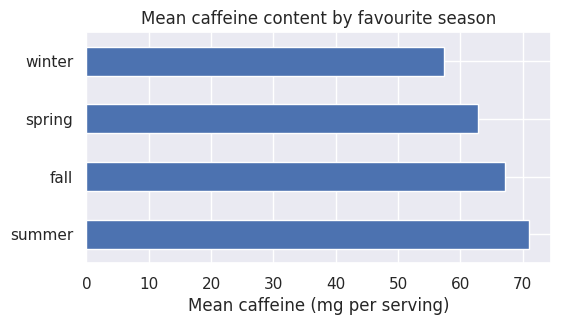

In [29]:
# Provided -- the complete Q8.2 shape.
#
# QUESTION:        Does caffeine choice track a season preference?
#
# WHY INTERESTING: The survey never asks "how much caffeine do you drink" -- we
#                  MANUFACTURED that number by joining a lookup table. If the joined
#                  column shows structure, the join bought us a real variable; if it
#                  shows nothing, we learn the lookup was too coarse. Either way the
#                  answer is about the enrichment, not just the data.
#
# APPROACH:        group by season, average the merged-in mg column, sort, plot.

by_season = (df.groupby("fav_season")["mg_per_serving"]
               .mean().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(6, 3))
by_season.plot(kind="barh", ax=ax)
ax.set_xlim(0, None)                       # from zero -- see Part 5
ax.set_xlabel("Mean caffeine (mg per serving)")
ax.set_ylabel("")
ax.set_title("Mean caffeine content by favourite season")
plt.show()

> **Interpretation.** *CLAIM (simulated data): mean lookup-caffeine runs from about
> 71 mg (summer) to 57 mg (winter) — a spread of roughly 14 mg, on a lookup table whose
> own values span 0 to 95 mg. Two things this plot does **not** tell you. First, whether
> 14 mg is more than these four groups would differ by anyway: four group means, drawn
> with no interval around them, cannot answer that — it would take a permutation test or
> bootstrap intervals, and neither is here. Second, this is not caffeine* consumption *: it
> is a number we attached to a stated beverage preference, so it varies only because the
> mix of beverages varies. Note the axis starts at zero; on a truncated axis those same
> 14 mg would have filled the plot and looked decisive.*

**Describing is not concluding.** The chart supports "these four means differ by about
14 mg". It does not support "season predicts caffeine" — and it does not support "season
doesn't predict caffeine" either, which is the overclaim that feels safe and isn't.

In [30]:
# Provided: save the enriched frame. HW1 Q8.3 asks for exactly this,
# minus any bulky page content.
df.to_csv("data/survey_enriched.csv", index=False)
print("wrote data/survey_enriched.csv:", df.shape)

wrote data/survey_enriched.csv: (297, 21)


<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 4 (2 min — optional, if you are ahead)</div>
<div>
<strong>With a neighbour.</strong> We used <code>how="left"</code>, which kept every survey row.

When would you <em>not</em> want that? And what would you expect to happen to the row count if
the lookup table accidentally listed <code>"coffee"</code> twice?
</div></div>

<div style="background:#F3F4F6; border-left:6px solid #4B5563; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🧠 Takeaways</div>
<div>
<ol>
<li><strong>A CSV file stores every value as text, so converting each column to the
    right dtype is the first thing to do after loading one.</strong> Until you do, sorting
    compares strings character by character rather than by value, arithmetic either fails
    or joins strings end to end, and grouping treats <code>"10"</code> and
    <code>"10.0"</code> as two different groups. → Q4.3</li>
<li><strong>Audit the frame, and print the counts you found.</strong> Report how many
    duplicate rows you dropped, how many rows are left, and how many rows have a missing
    value in any column. A number you printed is something your reader can check; a
    sentence saying the data "looks clean" is not. → Q4.1–4.2</li>
<li><strong>Display a slice of a DataFrame rather than the whole thing.</strong> Your
    notebook is submitted as a PDF that a person reads, and two thousand rows of output
    buries the work around it. Use <code>.head()</code>, or select the specific rows you
    want to show.</li>
<li><strong>A value that parses successfully can still be wrong.</strong> Three rows in
    this survey give a date of birth in the last year. <code>pd.to_datetime</code> accepted
    them because they are valid dates, so <code>errors="coerce"</code> did not flag them.
    Only checking the resulting ages against a plausible range found them. → Q4</li>
<li><strong><code>subplots(1, 2)</code> returns an array of Axes, which you index
    into.</strong> When you share an axis between the two panels, share the one holding the
    numbers: <code>sharey=True</code> for vertical bars, <code>sharex=True</code> for
    horizontal bars. Sharing the category axis instead forces two unrelated lists of labels
    onto one axis. → Q5.2</li>
<li><strong>Write a sentence underneath every plot, saying what it shows.</strong> Say what the plot lets you
    conclude, and why you chose that plot type rather than another one. A figure with no
    caption leaves the reader to guess what you meant them to notice. → Q5.3</li>
<li><strong>Code that runs without error can still produce a misleading chart.</strong>
    An axis that does not start at zero makes a small difference look large, a title that
    states a conclusion tells the reader what to see before they have looked, and a bar
    showing two group means hides the fact that the two groups overlap almost completely.
    Matplotlib will not warn you about any of these. → Q5.5</li>
<li><strong>Check the row counts and the unmatched keys after every join.</strong> Compare the row count going in with
    the row count coming out, and count the keys that did not match. A merge that quietly
    drops rows or duplicates them changes every number you compute afterwards. Then use the
    column you gained to answer a question. → Q8.1–8.2</li>
</ol>
</div></div>

---
# Appendix — for afterwards, and for HW1

**Not section material.** These are the HW1 moves that did not fit in seventy-one minutes,
each one provided and complete. Read them when you hit the matching question.

### A1. Ask your own question — bounded

HW1 Q5.4 asks you to pose a question of your own and answer it with a plot **whose type
differs** from the ones you used earlier. Here is the shape, with two blanks. Pick one:

1. Do students who sleep longer rate their Pandas skill differently?
2. Does the number of languages spoken vary by program?
3. Do dark-mode users wake earlier?

In [32]:
df

,program,jupyter,python_exp,pandas_skill,os,dark_mode,languages,continents,dob,wake_time,...,fav_season,caffeine,pet,fav_movie,fav_genres,hobbies,hw0,age,sleep_len,mg_per_serving
0,master's (ds),False,less than 1 year,3,macos,True,english,"asia, north america",2000-09-24,1900-01-01 07:30:00,...,summer,tea,pet rock,NaN,comedy,"reading, hiking",NaN,26.0,0 days 04:30:00,47.0
1,master's (ds),False,1-2 years,3,wsl,True,"english, cantonese, portuguese, hindi","asia, north america",2004-08-08,1900-01-01 10:00:00,...,spring,coffee,dog,Oppenheimer,drama,climbing,😀,22.1,0 days 10:45:00,95.0
2,mit master's,True,1-2 years,3,macos,False,"english, french, portuguese",north america,2008-01-07,1900-01-01 06:30:00,...,spring,tea,none,Oppenheimer,"action, sci-fi",climbing,🤞,18.7,0 days 06:30:00,47.0
3,bachelor's (cs),False,1-2 years,2,macos,True,"english, cantonese, mandarin, hindi","asia, north america",2008-01-07,1900-01-01 08:30:00,...,summer,tea,pet rock,Parasite,comedy,climbing,🤞,18.7,0 days 10:15:00,47.0
4,master's (ds) [extension school],True,1-2 years,3,windows,False,"english, hindi, mandarin","africa, asia, europe",2003-08-08,1900-01-01 08:15:00,...,summer,tea,fish,NaN,sci-fi,"reading, hiking",NaN,23.1,0 days 08:45:00,47.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,bachelor's (statistics),True,1-2 years,2,windows,True,"english, hindi, russian, portuguese","europe, north america",NaT,1900-01-01 07:00:00,...,winter,NaN,none,NaN,"action, sci-fi",climbing,🤞,NaN,0 days 08:30:00,NaN
293,bachelor's (cs),True,less than 1 year,2,macos,True,english,"asia, north america",2006-02-23,1900-01-01 08:15:00,...,spring,tea,fish,NaN,"comedy, drama",climbing,😀,20.5,0 days 10:15:00,47.0
294,mit master's,True,less than 1 year,2,windows,True,"english, japanese","asia, north america",1990-02-12,1900-01-01 11:15:00,...,fall,tea,dog,Interstellar,sci-fi,"music, running",NaN,36.6,0 days 11:30:00,47.0
295,bachelor's (cs),True,1-2 years,2,macos,True,english,north america,2006-02-21,1900-01-01 07:15:00,...,fall,coffee,none,Interstellar,horror,climbing,😀,20.5,0 days 07:30:00,95.0


In [44]:
df.groupby('pandas_skill')['sleep_len'].mean().sort_values()

,sleep_len
pandas_skill,
1,0 days 08:28:09.795918367
5,0 days 08:46:52.500000
3,0 days 08:51:12.413793103
4,0 days 09:02:51.428571428
2,0 days 09:14:12.127659574


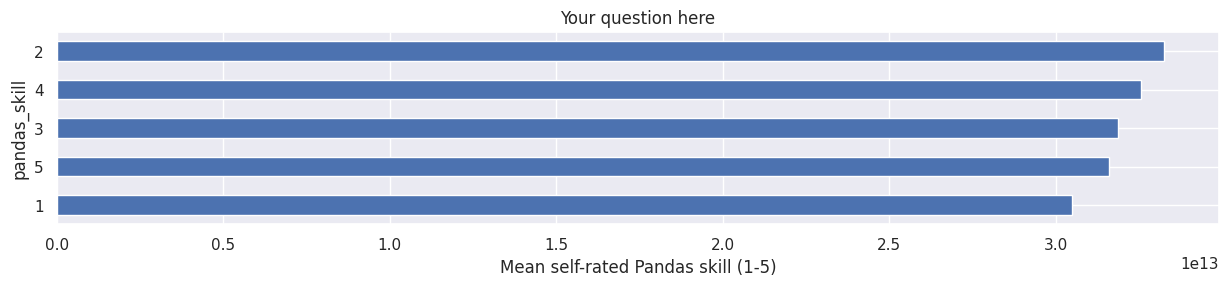

In [49]:
# Two blanks: the grouping column, and the aggregation.
# your code here
answer = df.groupby('...')['...'].mean().sort_values()                # student
answer = df.groupby('pandas_skill')['sleep_len'].mean().sort_values() # answer (REMOVE FOR THE STUDENT)

fig, ax = plt.subplots(figsize=(15, 2.5))
answer.plot(kind="barh", ax=ax)
ax.set_xlim(0, None)
ax.set_xlabel("Mean self-rated Pandas skill (1-5)")
ax.set_title("Your question here")
plt.show()

### A2. `sns.heatmap` on a pivot — HW1 Q9.1

Q9 investigates how many students voted for a given season as their favorite, for the selected top programs?

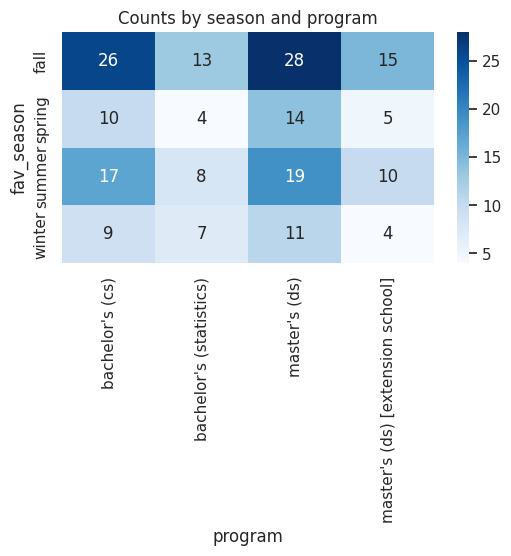

In [70]:
grid = df[df["program"].isin(top)].pivot_table(
    index="fav_season", columns="program", values="age",
    aggfunc="size", observed=False,
)

fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(grid, annot=True, fmt=".0f", cmap="Blues", ax=ax)
ax.set_title("Counts by season and program")
plt.show()

### A3. Profile tables — several aggregates at once

`groupby().agg()` builds the multi-column profile Q9.1 wants, in one call.

In [72]:
df.groupby("caffeine").agg(
    n=("age", "size"),
    median_age=("age", "median"),
    mean_skill=("pandas_skill", "mean"),
).round(2)

,n,median_age,mean_skill
caffeine,,,
coffee,136,24.3,2.54
energy drinks,22,23.5,2.32
no caffeine for me!,37,24.3,2.54
tea,99,24.0,2.53


### A4. Shares within a group, with a minimum-count guard

Among students in each program, what proportion prefer dark mode, and which programs have the highest dark-mode preference. The number of students should be at least 20?

In [74]:
counts = df.groupby("program").agg(n=("dark_mode", "size"),
                                   share_dark=("dark_mode", "mean"))
counts[counts["n"] >= 20].sort_values("share_dark", ascending=False).round(2)

,n,share_dark
program,,
bachelor's (cs),63,0.68
mit master's,24,0.67
master's (ds),73,0.66
master's (ds) [extension school],35,0.63
bachelor's (am),32,0.59
bachelor's (statistics),33,0.58


### A5. Ordered categories — and the silent NaN

`python_exp` has a natural order that alphabetical sorting destroys. An **ordered
categorical** teaches Pandas the real order. The guard matters: any value not in your
label list becomes NaN **silently**, so if the survey wording changes between years, a
column quietly empties.

In [75]:
from pandas.api.types import CategoricalDtype

exp_order = CategoricalDtype(
    ["less than 1 year", "1-2 years", "2-4 years", "4+ years"], ordered=True
)

# Verify BEFORE converting -- this is the whole point.
unknown = set(df["python_exp"].dropna()) - set(exp_order.categories)
assert not unknown, f"survey wording changed; these labels would become NaN: {unknown}"

df["python_exp"] = df["python_exp"].astype(exp_order)
df.groupby("python_exp", observed=False)["pandas_skill"].mean().round(2)

,pandas_skill
python_exp,
less than 1 year,1.74
1-2 years,2.39
2-4 years,3.19
4+ years,3.62


### A6. Multi-valued text: `.str.split` + `.explode`

`languages` packs several values into one string. HW1's `directors` and `genres` columns
do the same.

In [76]:
languages = df["languages"].dropna().str.split(", ").explode()
languages.value_counts().head(6)

,count
languages,
english,285
spanish,41
portuguese,39
japanese,39
german,38
korean,32


### A7. Why a CSV loses your dtypes and Parquet keeps them

In [77]:
reloaded = pd.read_csv("data/survey_enriched.csv")
reloaded[["dob", "age"]].dtypes

,0
dob,object
age,float64


`dob` is back to `object` — CSV stores text and nothing else. For pipeline intermediates
`df.to_parquet(...)` / `pd.read_parquet(...)` preserve dtypes exactly. For HW1, CSV plus
the conversions written down in your notebook is fine, because the notebook *is* the
record of how the types were made.

### A8. Merge validation beyond a row count

`validate=` makes Pandas raise on the duplicate-key case from Checkpoint 4, and
`indicator=True` tells you which side each row came from.

In [78]:
check = df.merge(caffeine_mg, on="caffeine", how="left",
                 validate="many_to_one", indicator=True, suffixes=("", "_dup"))
check["_merge"].value_counts()

,count
_merge,
both,294
left_only,3
right_only,0


### A9. `observed=False` on a categorical groupby

When you group by a categorical, Pandas defaults to showing **every declared category**,
including ones with no rows. `observed=True` shows only the ones present. Neither is
wrong — but a table with surprise empty rows, or a missing category you expected, is
usually this setting.

In [79]:
pd.concat({
    "observed=False": df.groupby("python_exp", observed=False).size(),
    "observed=True":  df.groupby("python_exp", observed=True).size(),
}, axis=1)

,observed=False,observed=True
python_exp,,
less than 1 year,96,96
1-2 years,100,100
2-4 years,54,54
4+ years,47,47


---
🌈 **That's Section 2.** The `README.md` beside this notebook has the pacing table and the
cut order; `TEACHING_METHOD.md` explains why it is built this way.

**For HW1:** Q4 is Parts 1–3, Q4.5 is Part 4, Q5 is Part 5, Q8 is Part 6. The two
supplementals — *Matplotlib & Seaborn reference* and *MediaWiki API* — carry what this
hour deliberately did not.